# Anexo A. Ejecución del estudio: bitácora, fallos y reparaciones

Los capítulos 02 y 03 presentan los 140 modelos como si se hubieran entrenado de una sola vez. En la
práctica, las 700 unidades de trabajo (140 combinaciones × 5 pliegues externos) se ejecutaron durante
algo más de ocho días en un portátil, con varias ventanas en paralelo, y durante ese tiempo hubo
fallos de memoria de la GPU, procesos que el sistema operativo terminó, suspensiones del equipo y una
estimación de tiempos que resultó cinco veces optimista. Este anexo documenta cómo se organizó la
ejecución, qué falló, cómo se reparó sin introducir fuga de información y qué consecuencias tiene, si
alguna, sobre los resultados.

Todo lo que se muestra se calcula a partir de lo que el propio estudio dejó en disco: el registro JSON
de cada unidad (`resultados/corridas/`), los registros de texto de cada ventana (`resultados/log_*.txt`),
la estimación previa de tiempos (`resultados/estimacion_tiempos_*.csv`) y la tabla de reparaciones
(`resultados/reparaciones.csv`).

In [1]:
# --- preambulo comun: localiza la raiz del libro y carga el paquete src ------
import os, sys, warnings
from pathlib import Path
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "_config.yml").is_file() and (p / "src").is_dir())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from src import config, graficos
config.fijar_semillas()
graficos.estilo()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
print(config.resumen())

Raiz del proyecto     : entregable3
Modo prueba           : False
Semilla               : 42
CV anidada            : 5 externos x 3 internos
Evaluaciones/optimiz. : 20
Nucleos               : 11   paralelo interno: True
XGBoost               : device='cuda'
Random Forest         : xgbrf   KNN: torch


In [2]:
import json, re

def recurso(r):
    # Donde se ejecuto la unidad: el bosque y XGBoost en la GPU; KNN segun su motor.
    if r["modelo"] in ("random_forest", "xgboost"):
        return "GPU"
    if r["modelo"] == "knn":
        return "CPU" if r.get("motor_knn") == "faiss" else "GPU"
    return "CPU"

filas, evals = [], []
for ruta in sorted(config.DIR_CORRIDAS.glob("*.json")):
    r = json.loads(ruta.read_text(encoding="utf-8"))
    seg = sum(float(r.get(k) or 0) for k in ("t_optimizacion", "t_reentreno", "t_inferencia"))
    rep = r.get("reparacion") or {}
    # Una unidad repetida en el cierre conserva en `reparacion` la fecha en que termino durante el
    # estudio; para la linea de tiempo del estudio se usa esa fecha.
    fecha = (rep.get("anterior") or {}).get("fecha") if rep.get("tipo") == "unidad_repetida" else None
    fin_ = pd.to_datetime(fecha or r["fecha"])
    filas.append({"clave": r["clave"], "tarea": r["tarea"], "modelo": r["modelo"],
                  "balanceo": r["balanceo"], "optimizador": r["optimizador"], "pliegue": r["pliegue"],
                  "recurso": recurso(r),
                  "motor_knn": (r.get("motor_knn") or "torch (no registrado)") if r["modelo"] == "knn" else None,
                  "fin": fin_, "inicio": fin_ - pd.to_timedelta(seg, unit="s"), "horas": seg / 3600,
                  "n_evaluaciones": r.get("n_evaluaciones"), "reparacion": rep.get("tipo"),
                  "python": (r.get("versiones") or {}).get("python")})
    for h in r.get("historial", []):
        e = {"clave": r["clave"], "tarea": r["tarea"], "modelo": r["modelo"], "balanceo": r["balanceo"],
             "optimizador": r["optimizador"], "t": h.get("t"), "segundos": h.get("segundos"),
             "error": h.get("error"), "error_original": h.get("error_original"),
             "reparada_cpu": bool(h.get("reparada_cpu")), "segundos_cpu": h.get("segundos_cpu")}
        e.update({f"p_{k}": v for k, v in (h.get("params") or {}).items()})
        evals.append(e)
U = pd.DataFrame(filas)
E = pd.DataFrame(evals)

inicio, fin = U["inicio"].min(), U["fin"].max()
reloj_h = (fin - inicio).total_seconds() / 3600
print(f"Unidades registradas        : {len(U)}")
print(f"Evaluaciones registradas    : {len(E):,}")
print(f"Horas de computo (suma)     : {U['horas'].sum():.1f} h")
print(f"Primera unidad (inicio aprox.): {inicio:%Y-%m-%d %H:%M}")
print(f"Ultima unidad terminada     : {fin:%Y-%m-%d %H:%M}")
print(f"Tiempo de reloj             : {reloj_h:.1f} h ({reloj_h / 24:.1f} dias)")
print(f"Paralelismo medio efectivo  : {U['horas'].sum() / reloj_h:.2f} unidades a la vez")
print("Version de Python en los registros:", ", ".join(sorted(U["python"].dropna().unique())))

Unidades registradas        : 700
Evaluaciones registradas    : 13,500
Horas de computo (suma)     : 444.5 h
Primera unidad (inicio aprox.): 2026-09-22 21:15
Ultima unidad terminada     : 2026-10-01 03:14
Tiempo de reloj             : 198.0 h (8.2 dias)
Paralelismo medio efectivo  : 2.25 unidades a la vez
Version de Python en los registros: 3.12.0


## A.1 Equipo y entorno

| Componente | Detalle |
|---|---|
| Equipo | Portátil con Windows 11 |
| CPU | Intel Core 5 210H, 12 hilos lógicos (el estudio usa 11 y deja uno al sistema) |
| Memoria | 16 GB de RAM |
| GPU | NVIDIA GeForce RTX 3050 Laptop, 6 GB de memoria |
| Entorno | Python 3.12 en un entorno virtual (`.venv`) con las versiones de `requirements.txt` |

La GPU se usó para XGBoost y para el bosque aleatorio de XGBoost (`tree_method="hist"`,
`device="cuda"`) y, en parte del estudio, para la búsqueda de vecinos de KNN con PyTorch.

## A.2 Cómo se organizó la ejecución

**Unidades atómicas.** La unidad de trabajo es la combinación (tarea, modelo, balanceo, optimizador,
pliegue externo): el bucle interno completo (20 evaluaciones × 3 pliegues internos), el reentreno
sobre el pliegue externo y su evaluación. Cada unidad terminada se escribe de forma atómica en un JSON
propio, con sus predicciones en un `.npz`. Una interrupción, por tanto, solo pierde la unidad en
curso; al relanzar, las unidades terminadas se saltan.

**Fuera de Jupyter, con el mismo código.** Las 700 unidades suman cientos de horas, de modo que no se
ejecutaron dentro de los cuadernos sino con `correr_estudio.py`, lanzado desde archivos `.bat` en
ventanas de consola. Cada ventana recorre una lista priorizada de modelos llamando a la misma función
`experimento.ejecutar` que usan los capítulos 02 y 03. Por eso, al ejecutar después esos capítulos de
arriba abajo, todas las unidades aparecen como "ya hechas" y el cuaderno muestra los resultados que
produce su propio código.

**Varias ventanas sin pisarse.** Antes de empezar una unidad, la ventana crea un archivo de bloqueo
(`resultados/bloqueos/<clave>.lock`) con su número de proceso, de forma exclusiva. Si otra ventana
llega a la misma unidad, la salta. Un bloqueo cuyo proceso ya no existe (una ventana cerrada o un
equipo reiniciado) se considera huérfano y se reclama.

| Ventana | Qué ejecutaba |
|---|---|
| GPU | Random Forest y XGBoost (clasificación y regresión) y, al principio, KNN con PyTorch |
| GPU2 | La misma lista en orden inverso; se descartó (sección A.6) |
| CPU, CPU2, CPU3 | Logística, árbol, Naive Bayes, SVM y los regresores lineales, SVR y árbol, en distinto orden |
| KNN_CPU | KNN de clasificación y regresión con FAISS en la CPU (mismos vecinos exactos) |

**El cierre.** Cuando las 700 unidades estuvieron completas, `correr_capitulos.py` revisó y reparó las
evaluaciones fallidas (sección A.7), ejecutó los capítulos 01 a 09 de arriba abajo en un kernel nuevo
y compiló el libro.

## A.3 Estimación previa frente al tiempo real

Antes de lanzar el estudio se midió una evaluación real por modelo y técnica de balanceo, con los
hiperparámetros del **centro** del espacio de búsqueda, y se proyectó el total (capítulo 02, sección 5).
La tabla compara esa proyección con las horas que cada modelo consumió realmente.

In [3]:
est = []
for t in ("clasificacion", "regresion"):
    ruta = config.DIR_RESULTADOS / f"estimacion_tiempos_{t}.csv"
    if ruta.is_file():
        est.append(pd.read_csv(ruta).assign(tarea=t))
if est:
    est = pd.concat(est)
    comp_t = pd.DataFrame({"horas_estimadas": est.groupby("modelo")["horas_combinacion"].sum(),
                           "horas_reales": U.groupby("modelo")["horas"].sum()}).dropna()
    comp_t["real / estimado"] = comp_t["horas_reales"] / comp_t["horas_estimadas"]
    comp_t = comp_t.sort_values("real / estimado", ascending=False)
    total = comp_t[["horas_estimadas", "horas_reales"]].sum()
    comp_t.loc["TOTAL"] = [total.iloc[0], total.iloc[1], total.iloc[1] / total.iloc[0]]
    display(comp_t.style.format(precision=2))
else:
    print("No se encontro la estimacion previa de tiempos.")

,horas_estimadas,horas_reales,real / estimado
modelo,,,
svr,0.47,26.28,55.87
logistica,1.87,84.35,45.14
svm,6.14,153.94,25.07
ridge,0.05,0.53,11.54
lasso,0.06,0.27,4.41
knn,10.64,43.45,4.08
arbol,3.55,13.56,3.82
xgboost,19.77,54.93,2.78
naive_bayes,0.56,1.05,1.87


**Lectura.** El estudio consumió 444.5 horas de cómputo frente a las 87.8 proyectadas: 5.1 veces más.
El error no se repartió por igual. En los modelos cuyo coste apenas depende de los hiperparámetros la
proyección fue razonable: Random Forest (1.5 veces), Naive Bayes (1.9), XGBoost (2.8), el árbol (3.8)
y KNN (4.1). La diferencia que queda en esos modelos se explica sobre todo por la competencia entre
ventanas: la estimación midió cada evaluación con el equipo libre y el estudio corrió con tres o
cuatro procesos compartiendo núcleos, memoria y disco. En cambio, en la logística (45 veces), SVM (25
veces), SVR (56 veces) y Ridge (11.5 veces, aunque sobre tiempos muy pequeños) la proyección falló por
completo, porque el centro del espacio no representa el coste del resto. La sección A.5 muestra dónde
estaba el coste: la penalización L1 de la logística, que en scikit-learn exige el solver SAGA, y el
núcleo lineal de SVM y SVR con C alto. **Lección:** una estimación de tiempos debe muestrear varias
configuraciones del espacio, incluidos sus extremos, y no solo su centro.

## A.4 Línea de tiempo

Cada punto de la curva es una unidad terminada. Las líneas verticales marcan los momentos en que se
(re)lanzó alguna ventana, según sus registros: el arranque inicial, los relanzamientos tras una
interrupción y los cambios de organización. La tabla siguiente lista los intervalos más largos en los
que no terminó ninguna unidad.

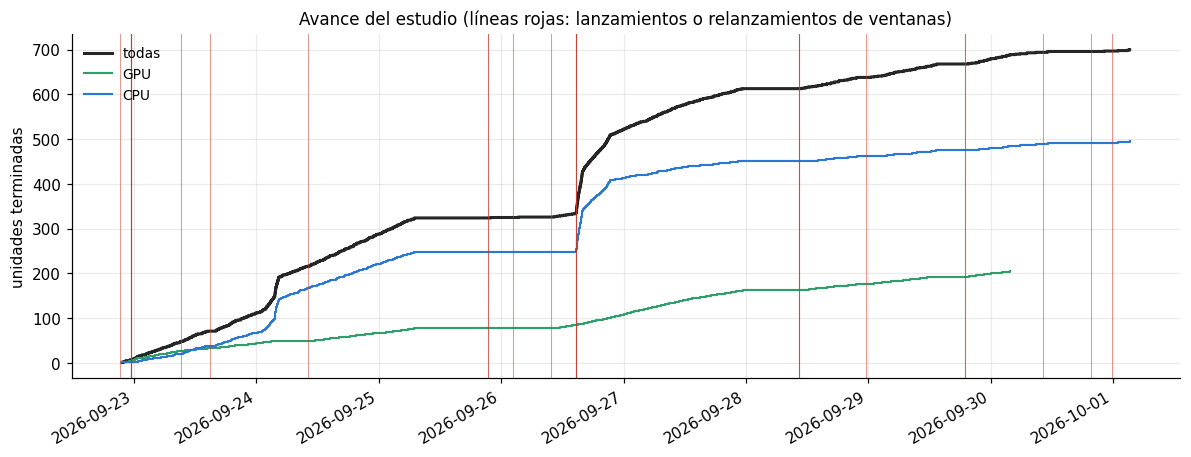

desde,hasta,horas
2026-09-25 06:59,2026-09-25 22:00,15.0
2026-09-27 23:19,2026-09-28 10:58,11.7
2026-09-30 11:13,2026-09-30 22:14,11.0
2026-09-26 03:20,2026-09-26 10:23,7.0
2026-09-29 13:21,2026-09-29 19:38,6.3
2026-09-25 22:00,2026-09-26 03:20,5.3
2026-09-30 22:14,2026-10-01 00:59,2.8
2026-09-28 21:49,2026-09-29 00:26,2.6


Lanzamientos por ventana:


,lanzamientos,primero,ultimo
ventana,,,
CPU,10,2026-09-22 21:15:39,2026-09-30 23:46:30
CPU2,9,2026-09-22 23:29:36,2026-09-30 23:46:30
CPU3,6,2026-09-25 21:28:20,2026-09-30 10:10:59
GPU,11,2026-09-22 21:15:39,2026-09-29 18:56:00
GPU2,1,2026-09-22 23:29:23,2026-09-22 23:29:23
KNN_CPU,2,2026-09-23 09:16:06,2026-09-23 14:49:36


In [4]:
# Lanzamientos y firmas de error en los registros de cada ventana (no se imprime ninguna linea:
# los registros contienen trazas con rutas del equipo).
FIRMAS = {
    "memoria de la GPU agotada": r"^xgboost\.core\.XGBoostError: .*cudaErrorMemoryAllocation",
    "proceso de loky terminado": r"^joblib\.externals\.loky\.process_executor\.TerminatedWorkerError",
    "recursos del sistema insuficientes (WinError 1450)": r"^OSError: \[WinError 1450\]",
}
lanzamientos, firmas = [], []
for ruta in sorted(config.DIR_RESULTADOS.glob("log_*.txt")):
    texto = ruta.read_text(encoding="utf-8", errors="replace")
    for m in re.finditer(r"^===== Grupo (\S+) \| inicio (\d{4}-\d\d-\d\d \d\d:\d\d:\d\d) =====", texto, re.M):
        lanzamientos.append({"ventana": m.group(1), "inicio": pd.to_datetime(m.group(2))})
    if re.search(r"^===== Grupo ", texto, re.M):
        fila = {"ventana": ruta.stem.replace("log_", "").upper()}
        fila.update({k: len(re.findall(p, texto, re.M)) for k, p in FIRMAS.items()})
        firmas.append(fila)
lanzamientos = pd.DataFrame(lanzamientos, columns=["ventana", "inicio"])
firmas = pd.DataFrame(firmas)

fig, ax = plt.subplots(figsize=(13, 4.6))
u = U.sort_values("fin")
ax.step(u["fin"], np.arange(1, len(u) + 1), where="post", color="0.15", lw=2, label="todas")
for rec, color in (("GPU", "#2f9e6b"), ("CPU", "#2a78d4")):
    v = u[u["recurso"] == rec]
    ax.step(v["fin"], np.arange(1, len(v) + 1), where="post", color=color, lw=1.4, label=rec)
for t in lanzamientos["inicio"].drop_duplicates():
    ax.axvline(t, color="#c0392b", lw=0.7, alpha=0.5)
ax.set_ylabel("unidades terminadas")
ax.set_title("Avance del estudio (líneas rojas: lanzamientos o relanzamientos de ventanas)")
ax.legend(loc="upper left")
fig.autofmt_xdate()
graficos.guardar(fig, "A1_linea_de_tiempo")
plt.show()

# intervalos sin ninguna unidad terminada
fins = u["fin"].drop_duplicates().sort_values().reset_index(drop=True)
huecos = pd.DataFrame({"desde": fins[:-1].to_numpy(), "hasta": fins[1:].to_numpy()})
huecos["horas"] = (huecos["hasta"] - huecos["desde"]).dt.total_seconds() / 3600
display(huecos.sort_values("horas", ascending=False).head(8)
        .style.format({"horas": "{:.1f}", "desde": "{:%Y-%m-%d %H:%M}", "hasta": "{:%Y-%m-%d %H:%M}"})
        .hide(axis="index"))
print("Lanzamientos por ventana:")
display(lanzamientos.groupby("ventana")["inicio"].agg(["count", "min", "max"])
        .rename(columns={"count": "lanzamientos", "min": "primero", "max": "ultimo"}))

**Lectura.** El estudio arrancó la noche del 22 de septiembre y terminó la madrugada del 1 de
octubre. Las mesetas de la curva y los relanzamientos marcan las interrupciones, que tuvieron cuatro
causas distintas:

1. **El primer arranque (22 de septiembre).** Las ventanas de CPU registraron procesos de `loky`
   terminados por el sistema operativo y la organización se rehízo esa misma noche: se relanzó con
   más ventanas y una lista de prioridades distinta.
2. **El bloqueo de la GPU (24 de septiembre).** Tras varias evaluaciones de Random Forest que agotaron
   la memoria de la GPU (sección A.6), el proceso de la ventana GPU dejó de avanzar después del último
   error, a las 3:44 de la madrugada, y no se recuperó hasta que se relanzó a las 10:11.
3. **Suspensiones y apagados del equipo.** El portátil usa el *modo de espera moderno* de Windows: tras
   unos minutos sin uso entra en un estado de bajo consumo que congela los programas, aunque esté
   conectado a la corriente. El registro de eventos de Windows mostró, por ejemplo, que el 30 de
   septiembre el equipo estuvo en ese modo de 11:21 a 19:33 y de 21:01 a 23:29. Se resolvió poniendo
   en "nunca" la suspensión, la hibernación y el apagado de pantalla con el equipo enchufado
   (`powercfg`). A esto se sumaron apagados para transportar el equipo y un reinicio el 30 de
   septiembre hacia las 23:40, que hizo perder las dos unidades de SVM que estaban en curso (una
   llevaba unas 4 horas); se repitieron desde cero.
4. **Cambios de organización.** Varios relanzamientos fueron deliberados: mover KNN a la CPU, probar
   y descartar la segunda ventana de GPU, o reducir de tres a dos las ventanas de SVM (sección A.6).

La tabla de intervalos lo confirma: los tres más largos sin ninguna unidad terminada (15 horas el 25
de septiembre, 11.7 horas entre el 27 y el 28 y 11 horas el 30) terminan en un relanzamiento de todas
las ventanas, es decir, son periodos con el equipo apagado o suspendido, no unidades largas. Entre la
mañana del 25 y la tarde del 26 el avance casi se detuvo: a esas horas sin equipo se sumaron tres
relanzamientos seguidos (21:28, 2:14 y la mañana del 26) en los que solo corrían unidades lentas
—logística L1, SVM y Random Forest, de una a varias horas cada una—. El salto de la tarde del 26
corresponde a la entrada del árbol y Naive Bayes, cuyas unidades terminan en minutos.

Que el tiempo de reloj fuera de unos ocho días para ~444 horas de cómputo implica un paralelismo
medio de algo más de dos unidades simultáneas, por debajo de las tres o cuatro ventanas que estuvieron
abiertas la mayor parte del tiempo: las interrupciones explican la diferencia. Ninguna afectó a los
resultados, porque la unidad interrumpida se repetía completa al relanzar.

## A.5 Dónde se fue el tiempo

In [5]:
por_modelo = (U.groupby(["tarea", "modelo"])
              .agg(unidades=("clave", "size"), horas=("horas", "sum"),
                   min_por_unidad_mediana=("horas", lambda s: 60 * s.median()),
                   min_por_unidad_max=("horas", lambda s: 60 * s.max())))
seg = (E.groupby(["tarea", "modelo"])["segundos"]
       .agg(s_eval_mediana="median", s_eval_p95=lambda s: s.quantile(0.95), s_eval_max="max"))
por_modelo = por_modelo.join(seg).sort_values("horas", ascending=False)
display(por_modelo.style.format(precision=1))

print("Logistica: segundos por evaluacion (3 pliegues internos) segun la penalizacion")
lg = E[E["modelo"] == "logistica"]
if "p_penalizacion" in lg:
    display(lg.groupby("p_penalizacion")["segundos"]
            .describe(percentiles=[0.5, 0.95])[["count", "50%", "95%", "max"]].style.format(precision=1))

print("SVM y SVR: segundos por evaluacion segun el nucleo y C")
sv = E[E["modelo"].isin(["svm", "svr"])].copy()
if {"p_nucleo", "p_C"} <= set(sv.columns):
    sv["C"] = pd.cut(sv["p_C"].astype(float), [0, 1e-3, 1e-2, 1e-1, np.inf],
                     labels=["C < 0.001", "0.001-0.01", "0.01-0.1", "C ≥ 0.1"])
    display(sv.pivot_table(index=["modelo", "p_nucleo"], columns="C", values="segundos",
                           aggfunc="median", observed=False).style.format(precision=0, na_rep="-"))

print("KNN: motor de busqueda de vecinos por unidad")
display(U[U["modelo"] == "knn"].groupby(["tarea", "motor_knn"]).size().rename("unidades").to_frame())

Logistica: segundos por evaluacion (3 pliegues internos) segun la penalizacion


,count,50%,95%,max
p_penalizacion,,,,
l1,832.0,287.2,538.1,4905.5
l2,768.0,11.4,29.3,168.2


SVM y SVR: segundos por evaluacion segun el nucleo y C


KNN: motor de busqueda de vecinos por unidad


unidades
tarea         motor_knn                      
clasificacion faiss                        80
regresion     faiss                        15
              torch (no registrado)         5

**Lectura.** SVM concentra un tercio de todo el cómputo del estudio, y la logística casi una quinta
parte, a pesar de ser dos de los modelos más sencillos. Las dos tablas inferiores muestran por qué.
En la logística, una evaluación con penalización L1 —que scikit-learn resuelve con SAGA— tarda una
mediana de 287 s frente a 11 s con L2 y lbfgs, 25 veces más, consistente con lo que midió el capítulo
05: con datos densos SAGA necesita muchas épocas para converger. En SVM y SVR el coste lo dispara el
núcleo lineal con C alto: a medida que C crece, el problema de `LinearSVC` (y de `LinearSVR`) se vuelve
peor condicionado y la mediana por evaluación pasa de menos de un minuto con C < 0.001 a unos 7-10
minutos con C entre 0.01 y 0.1 y a 18-20 minutos con C ≥ 0.1, mientras que con la aproximación de
Nystroem se mantiene por debajo de un minuto y medio con cualquier C. Ninguno de los dos
casos aparecía en la estimación previa: el centro del espacio que se midió (C ≈ 0.03, penalización L2
en la logística y núcleo de Nystroem en SVM y SVR) es justamente la combinación rápida, y las lentas
—L1 y núcleo lineal con C alto— no se midieron.

El cambio de motor de KNN se refleja en la última tabla: las 80 unidades de clasificación y 15 de
las 20 de regresión se ejecutaron con FAISS en la CPU; solo las 5 primeras de regresión, anteriores a
la ventana KNN_CPU (y al registro del motor), usaron PyTorch en la GPU. Ambos hacen búsqueda exacta, de modo que encuentran los mismos vecinos y
el cambio no afecta a los resultados (capítulo 05, sección 3).

## A.6 Fallos durante el estudio y cómo se resolvieron

Primero, el inventario objetivo: cuántas veces aparece cada tipo de error en los registros de cada
ventana y qué quedó registrado en las unidades.

In [6]:
if len(firmas):
    display(firmas.set_index("ventana"))

def causa(error):
    e = (error or "").lower()
    if "cudaerrormemoryallocation" in e or "out of memory" in e or "bad allocation" in e:
        return "memoria de la GPU"
    if "winerror" in e or "terminatedworker" in e or "brokenprocesspool" in e:
        return "sistema operativo"
    return "otra"

E["causa"] = [causa(a or b) for a, b in zip(E["error_original"], E["error"])]
fallidas = E[E["error"].notna() | E["error_original"].notna()]
print(f"Evaluaciones que fallaron durante el estudio y quedaron registradas: {len(fallidas)}")
print(f"  reparadas en la CPU : {int(fallidas['reparada_cpu'].sum())}")
print(f"  aun con error       : {int(E['error'].notna().sum())}")
if len(fallidas):
    display(fallidas.groupby(["modelo", "balanceo", "optimizador", "causa"]).size()
            .rename("evaluaciones").to_frame())
    cols = [c for c in ("p_n_estimators", "p_max_depth", "p_min_samples_leaf", "p_max_features",
                        "p_max_samples") if c in fallidas]
    if cols:
        print("Configuraciones de Random Forest que no cupieron en la GPU:")
        display(fallidas[fallidas["causa"] == "memoria de la GPU"].groupby(cols).size()
                .rename("evaluaciones").to_frame())
print("Unidades con reparacion registrada:")
display(U["reparacion"].value_counts().rename("unidades").to_frame())

,memoria de la GPU agotada,proceso de loky terminado,recursos del sistema insuficientes (WinError 1450)
ventana,,,
CPU,0,3,0
CPU2,0,1,1
CPU3,0,1,1
GPU,11,0,0
GPU2,0,0,0
KNN_CPU,0,0,0


Evaluaciones que fallaron durante el estudio y quedaron registradas: 20
  reparadas en la CPU : 20
  aun con error       : 0


evaluaciones
modelo        balanceo optimizador causa                          
random_forest adasyn   rejilla     memoria de la GPU            10
              smote    rejilla     memoria de la GPU            10

Configuraciones de Random Forest que no cupieron en la GPU:


,,,,,evaluaciones
p_n_estimators,p_max_depth,p_min_samples_leaf,p_max_features,p_max_samples,
100.0,16.0,20.0,0.02,0.5,10
300.0,16.0,20.0,0.02,0.5,10


Unidades con reparacion registrada:


,unidades
reparacion,
memoria_gpu_evaluada_en_cpu,10
unidad_repetida,1


El inventario cuenta 11 errores de memoria de la GPU en el registro de la ventana GPU, 5 procesos de
`loky` terminados y 2 errores `WinError 1450` en las ventanas de CPU. En las unidades guardadas
quedaron registradas 20 evaluaciones fallidas, todas de Random Forest con rejilla (10 con SMOTE y 10
con ADASYN) y con solo dos configuraciones —profundidad 16, hoja mínima 20, 2 % de columnas y 100 o 300
árboles—; las 20 se repararon (sección A.7). Los fallos del sistema que interrumpieron una unidad
completa no dejaron rastro en los resultados porque esa unidad se repitió al relanzar; la única que se
guardó con una evaluación afectada es la de SVM que se repitió en el cierre.

La tabla siguiente resume cada incidente, su causa y su consecuencia.

| Incidente | Qué se observó | Causa | Consecuencia y solución |
|---|---|---|---|
| Memoria de la GPU agotada | Algunas evaluaciones de Random Forest con SMOTE o ADASYN fallaron con `cudaErrorMemoryAllocation` | La configuración de profundidad 16, hoja mínima 20 y 2 % de columnas por nodo sobre los datos sobremuestreados pide más de los 6 GB de la GPU | Dentro de una unidad, la evaluación fallida puntúa 0 y el optimizador sigue. Al cierre se evaluaron en la CPU (sección A.7) |
| GPU bloqueada tras los errores de memoria | El 24 de septiembre la ventana GPU dejó de avanzar tras el último error (3:44) | El proceso quedó en un estado inconsistente después de varios fallos de asignación | Unas 6 horas perdidas; se relanzó la ventana. No afectó a los resultados |
| Dos procesos en la GPU | Con la ventana GPU2 abierta, una unidad de Random Forest pasó de 25.7 a 68.5 minutos | Los dos procesos compiten por la misma GPU y por la transferencia de datos | Ninguna ganancia neta: se cerró GPU2 y se mantuvo un único proceso en la GPU |
| KNN ocupando la GPU | KNN con PyTorch competía por la GPU con Random Forest y XGBoost | Un solo dispositivo para tres modelos | KNN pasó a la CPU con FAISS (búsqueda exacta, mismos vecinos); el motor quedó registrado en cada unidad |
| Procesos de `loky` terminados | `TerminatedWorkerError` en las ventanas de CPU | Procesos auxiliares de los pliegues internos terminados por el sistema operativo, lo más probable por presión de memoria con varias ventanas abiertas | La unidad no se guardaba y se repetía completa al relanzar |
| Recursos del sistema insuficientes | `WinError 1450` con tres ventanas de SVM a la vez, y una evaluación de SVM con ADASYN fallida dentro de una unidad | Agotamiento de recursos del sistema (memoria de páginas del núcleo) con tres procesos de SVM sobre datos sobremuestreados | Se redujo a dos ventanas de SVM. La unidad afectada se repitió completa al cierre (sección A.7) |
| Evaluaciones muy lentas | Logística L1 y SVM/SVR lineales con C alto, de minutos a media hora por evaluación | SAGA y `LinearSVC`/`LinearSVR` mal condicionados (sección A.5) | El estudio tardó 5 veces lo previsto; se abrieron más ventanas de CPU para compensar |
| Suspensiones, apagados y un reinicio | Ventanas congeladas o cerradas; mesetas en la línea de tiempo | Modo de espera moderno de Windows, traslados del equipo y un reinicio | Se pierde como mucho la unidad en curso, que se repite desde cero. Se desactivó la suspensión con el equipo enchufado |

Ningún incidente obligó a cambiar el diseño experimental: se mantuvieron la validación cruzada anidada
5 × 3, las 20 evaluaciones por optimizador y el conjunto de datos completo.

## A.7 Reparación sin fuga de información

Al terminar el estudio, `src/reparacion.py` revisó todas las evaluaciones fallidas y las trató según
su causa:

* **Fallo del sistema** (`WinError`, procesos terminados): no depende de la configuración evaluada, así
  que la unidad completa se borra y se repite desde cero con el equipo libre, igual que cualquier otra.
* **Memoria de la GPU con rejilla o búsqueda aleatoria**: estas configuraciones se fijan antes de ver
  ningún resultado, de modo que evaluarlas después equivale a haberlas evaluado en su momento. Se
  evalúan en la CPU (mismo algoritmo de XGBoost, otro dispositivo) sobre los mismos pliegues internos.
  La ganadora se elige **solo por el AUC interno**; si cambiara, se reentrenaría en la CPU y se
  recalcularía el AUC externo, subiera o bajara. Toda unidad tratada queda marcada en su JSON.
* **Memoria de la GPU con optimización bayesiana o genética**: no se repara, porque cada punto depende
  de los anteriores y reevaluar cambiaría la trayectoria. Se documentaría como configuración no
  factible en el hardware. En este estudio no hubo ningún caso.

In [7]:
ruta = config.DIR_RESULTADOS / "reparaciones.csv"
if ruta.is_file():
    rep = pd.read_csv(ruta)
    display(rep.style.format(precision=4, na_rep="-").hide(axis="index"))
else:
    print("No hay reparaciones registradas.")

clave,resultado,evaluaciones_reparadas,auc_interno_antes,auc_externo_antes,cambio_ganador,auc_interno_despues
clasificacion__svm__adasyn__genetica__e3,unidad repetida,-,-,-,-,-
clasificacion__random_forest__adasyn__rejilla__e0,-,2.0000,0.7304,0.7277,False,0.7304
clasificacion__random_forest__adasyn__rejilla__e1,-,2.0000,0.7298,0.7376,False,0.7298
clasificacion__random_forest__adasyn__rejilla__e2,-,2.0000,0.7294,0.7299,False,0.7294
clasificacion__random_forest__adasyn__rejilla__e3,-,2.0000,0.7302,0.7321,False,0.7302
clasificacion__random_forest__adasyn__rejilla__e4,-,2.0000,0.7323,0.7286,False,0.7323
clasificacion__random_forest__smote__rejilla__e0,-,2.0000,0.7301,0.7258,False,0.7301
clasificacion__random_forest__smote__rejilla__e1,-,2.0000,0.7289,0.7360,False,0.7289
clasificacion__random_forest__smote__rejilla__e2,-,2.0000,0.7305,0.7306,False,0.7305
clasificacion__random_forest__smote__rejilla__e3,-,2.0000,0.7311,0.7337,False,0.7311


**Lectura.** La reparación no cambió ningún resultado. La unidad de SVM afectada por el fallo del
sistema se repitió completa y dio exactamente el mismo AUC externo que antes (0.7432), lo esperable
con semillas fijas, y confirma que el fallo no había contaminado la unidad original. Las evaluaciones
de Random Forest que no cupieron en la GPU se evaluaron en la CPU, y en ninguna de las diez unidades
afectadas su AUC interno superó al de la configuración ganadora: el AUC interno y el externo quedaron
idénticos. La razón es que esas configuraciones —árboles profundos con hojas pequeñas sobre datos
sobremuestreados— no estaban entre las mejores del espacio.

## A.8 Cierre del libro

El cierre se ejecutó con `correr_capitulos.py` (`ESPERAR_Y_CORRER_CAPITULOS.bat` esperaba a que
terminaran las 700 unidades y lo lanzaba solo): revisión y reparación de fallos, capítulos 01 a 09 de
arriba abajo en un kernel nuevo, guardando sus salidas, y compilación del libro. La primera ejecución
completa terminó sin errores el 1 de octubre. Al revisarla se encontraron y corrigieron detalles de
presentación, y se volvieron a ejecutar todos los capítulos:

* algunas salidas imprimían rutas absolutas del equipo (la raíz del proyecto y la carpeta de los
  datos); ahora se muestra solo el nombre de la carpeta;
* tres avisos de bibliotecas aparecían en las salidas: uno de pandas por un `DataFrame` fragmentado
  (se consolida antes de guardar), el de SAGA al no converger (ahora es una columna de la tabla del
  capítulo 05, porque es un resultado) y uno de XGBoost al predecir en la CPU con un modelo de la GPU
  (LIME predice ahora en la CPU);
* tres celdas de título duplicadas del capítulo 01 generaban errores de formato en el libro, y las
  advertencias de la compilación venían de que Jupyter Book leía el entorno virtual, que ahora se
  excluye.

## A.9 Lecciones

1. **Estimar con varias configuraciones, no con el centro.** El coste de la logística L1 y del SVM
   lineal depende de los hiperparámetros en dos órdenes de magnitud; una sola medición en el centro
   subestimó el estudio cinco veces.
2. **Acotar el espacio por memoria antes de lanzar.** Probar las configuraciones extremas de cada modelo
   en la GPU (máxima profundidad con la mínima hoja sobre los datos sobremuestreados) habría evitado
   los errores de memoria y el bloqueo de la GPU.
3. **Preferir hilos a procesos cuando el trabajo libera el GIL.** Los procesos de `loky` fueron la
   fuente de dos tipos de fallo y, según el capítulo 05, no aportan velocidad en ese caso.
4. **Preparar el equipo para ejecuciones largas.** Desactivar la suspensión y la hibernación con el
   equipo enchufado y pausar las actualizaciones automáticas antes de empezar.
5. **Guardar cada unidad de forma atómica.** Fue la decisión que hizo que ninguno de estos incidentes
   afectara a los resultados: cada interrupción costó tiempo, nunca datos.